In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [142]:
df = pd.read_csv('/kaggle/input/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows/imdb_top_1000.csv')

In [143]:
def dataset_glance(dataset):
    print(dataset.head(5));print('\n')
    print(dataset.shape);print('\n')
    print(dataset.columns);print('\n')
    print(dataset.isnull().sum());print('\n')

In [144]:
dataset_summarization = dataset_glance(df)
print(dataset_summarization)

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [145]:
dataset = df[['Overview', 'IMDB_Rating']]

In [146]:
dataset['Label'] = (df['IMDB_Rating'] >= 8.0).astype(int)

/tmp/ipykernel_59/2329643632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Label'] = (df['IMDB_Rating'] >= 8.0).astype(int)


In [147]:
X = dataset['Overview']
y = dataset['Label']

/tmp/ipykernel_59/4189195574.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Word_Count'] = dataset['Overview'].apply(lambda x: len(str(x).split()))
/tmp/ipykernel_59/4189195574.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Label")


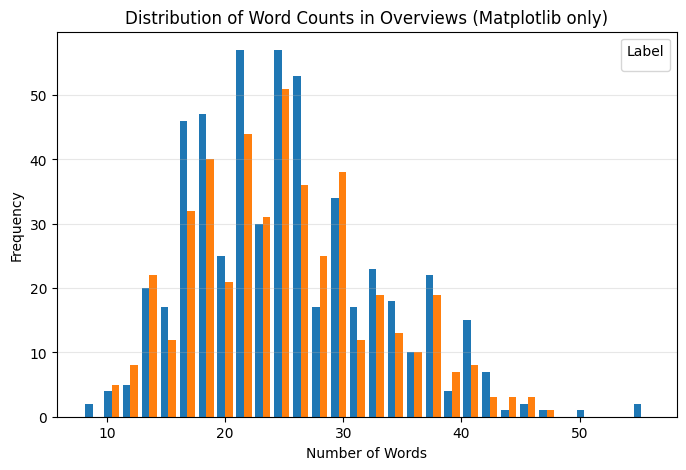

In [148]:
dataset['Word_Count'] = dataset['Overview'].apply(lambda x: len(str(x).split()))

words_class_0 = dataset[dataset['Label'] == 0]['Word_Count']
words_class_1 = dataset[dataset['Label'] == 1]['Word_Count']

plt.figure(figsize=(8,5))
plt.hist([words_class_0, words_class_1], bins=30)
plt.title("Distribution of Word Counts in Overviews (Matplotlib only)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend(title="Label")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [149]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop = stopwords.words('english')
lem = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    for p in '.,!?;:()[]\"':
        text = text.replace(p, '')

    words = text.split()

    good_words = []
    for w in words:
        if w not in stop:
            root_word = lem.lemmatize(w)
            good_words.append(root_word)

    return ' '.join(good_words)

In [150]:
dataset['cleaned_overview'] = dataset['Overview'].apply(clean_text)

print(dataset['Overview'][10])

print(dataset['cleaned_overview'][10])

A meek Hobbit from the Shire and eight companions set out on a journey to destroy the powerful One Ring and save Middle-earth from the Dark Lord Sauron.
meek hobbit shire eight companion set journey destroy powerful one ring save middle-earth dark lord sauron


/tmp/ipykernel_59/1109671525.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['cleaned_overview'] = dataset['Overview'].apply(clean_text)


In [185]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)

X = vectorizer.fit_transform(dataset['Overview'])

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [187]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [188]:
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [189]:
y_pred = lr_model.predict(X_test)

In [190]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(accuracy);print(cm)

0.515
[[54 51]
 [46 49]]
